# Shelly Group SE (BSE: SLYG / OTC: SHELY) — Financial Model

**Comprehensive bottom-up financial model with 3-statement projections, DCF valuation, and scenario analysis.**

Data sources: FY2025 consolidated financial results, Montega AG research (Dec 2025), corporate IR presentations, StockAnalysis.com

All monetary values in EUR thousands unless stated otherwise.

In [1]:
# ============================================================
# CELL 1: SETUP & IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# Color palette
COLORS = {
    'primary': '#1a73e8',
    'secondary': '#34a853',
    'accent': '#ea4335',
    'neutral': '#5f6368',
    'light': '#a8d5e2',
    'gold': '#f9ab00',
    'purple': '#9c27b0',
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Cell 2: Annual Income Statement (EUR thousands) ──────────
# FY2022 from Yahoo Finance / annual report; FY2023-2025 from consolidated results
# Note: Shelly reports in BGN; converted at fixed rate 1 EUR = 1.95583 BGN

income_stmt = pd.DataFrame({
    'Revenue':              [47_600,  74_900, 106_700, 149_700],
    'COGS':                 [23_700,  32_100,  43_100,  63_100],
    'Gross_Profit':         [23_900,  42_800,  63_600,  86_600],
    'Personnel_Expense':    [ 5_200,   8_500,  14_200,  22_000],  # incl. mgmt share program
    'Selling_Expense':      [ 5_800,   8_200,  12_500,  17_500],
    'RD_Expense':           [ 2_100,   3_200,   4_800,   7_200],
    'Other_OpEx':           [ 2_200,   3_800,   6_900,   9_600],
    'Total_OpEx':           [15_300,  23_700,  38_400,  56_300],
    'EBIT_Reported':        [ 8_600,  19_100,  25_200,  30_300],
    'EBIT_Adjusted':        [ 8_600,  19_100,  26_400,  37_700],  # adj for mgmt share program
    'Finance_Income':       [   200,     400,     600,     800],
    'Finance_Expense':      [  -300,    -500,    -800,  -1_200],
    'Pretax_Income':        [ 8_500,  19_000,  25_000,  29_900],
    'Tax':                  [  -900,  -2_200,  -2_800,  -4_400],
    'Net_Income':           [ 7_600,  16_800,  22_200,  25_500],
    'DA':                   [   800,   1_000,   1_900,   2_500],
    'EBITDA':               [ 9_400,  20_100,  28_100,  39_000],  # EBIT_adj + D&A approx
    'SBC_MgmtProgram':      [     0,       0,   1_200,   7_400],  # non-cash share program
    'Shares_Outstanding_K': [17_606,  17_606,  18_106,  18_106],
    'EPS':                  [  0.43,    0.95,    1.23,    1.41],
    'EPS_Adjusted':         [  0.43,    0.95,    1.30,    1.77],
}, index=[2022, 2023, 2024, 2025])
income_stmt.index.name = 'Year'

# Derived metrics
income_stmt['Gross_Margin'] = income_stmt['Gross_Profit'] / income_stmt['Revenue'] * 100
income_stmt['EBIT_Margin_Adj'] = income_stmt['EBIT_Adjusted'] / income_stmt['Revenue'] * 100
income_stmt['EBITDA_Margin'] = income_stmt['EBITDA'] / income_stmt['Revenue'] * 100
income_stmt['Net_Margin'] = income_stmt['Net_Income'] / income_stmt['Revenue'] * 100
income_stmt['Tax_Rate'] = -income_stmt['Tax'] / income_stmt['Pretax_Income'] * 100

print('═' * 70)
print('SHELLY GROUP SE — ANNUAL INCOME STATEMENT (EUR K)')
print('═' * 70)
display_cols = ['Revenue', 'COGS', 'Gross_Profit', 'Gross_Margin',
                'EBIT_Adjusted', 'EBIT_Margin_Adj', 'EBITDA', 'EBITDA_Margin',
                'Net_Income', 'Net_Margin', 'EPS_Adjusted']
print(income_stmt[display_cols].T.to_string(float_format=lambda x: f'{x:,.1f}'))

══════════════════════════════════════════════════════════════════════
SHELLY GROUP SE — ANNUAL INCOME STATEMENT (EUR K)
══════════════════════════════════════════════════════════════════════
Year                2022     2023      2024      2025
Revenue         47,600.0 74,900.0 106,700.0 149,700.0
COGS            23,700.0 32,100.0  43,100.0  63,100.0
Gross_Profit    23,900.0 42,800.0  63,600.0  86,600.0
Gross_Margin        50.2     57.1      59.6      57.8
EBIT_Adjusted    8,600.0 19,100.0  26,400.0  37,700.0
EBIT_Margin_Adj     18.1     25.5      24.7      25.2
EBITDA           9,400.0 20,100.0  28,100.0  39,000.0
EBITDA_Margin       19.7     26.8      26.3      26.1
Net_Income       7,600.0 16,800.0  22,200.0  25,500.0
Net_Margin          16.0     22.4      20.8      17.0
EPS_Adjusted         0.4      0.9       1.3       1.8


In [3]:
# ── Cell 3: Expense Breakdown (EUR thousands) ────────────────

expense_detail = pd.DataFrame({
    'COGS':               [23_700, 32_100, 43_100, 63_100],
    'Personnel':          [ 5_200,  8_500, 14_200, 22_000],
    'Selling_Distribution':[ 5_800, 8_200, 12_500, 17_500],
    'R_and_D':            [ 2_100,  3_200,  4_800,  7_200],
    'Other_Operating':    [ 2_200,  3_800,  6_900,  9_600],
    'Mgmt_Share_Program': [     0,      0,  1_200,  7_400],
}, index=[2022, 2023, 2024, 2025])
expense_detail.index.name = 'Year'

# Express as % of revenue
expense_pct = expense_detail.div(income_stmt['Revenue'], axis=0) * 100

print('═' * 70)
print('EXPENSE BREAKDOWN (EUR K)')
print('═' * 70)
print(expense_detail.T.to_string(float_format=lambda x: f'{x:,.0f}'))
print()
print('═' * 70)
print('EXPENSE AS % OF REVENUE')
print('═' * 70)
print(expense_pct.T.to_string(float_format=lambda x: f'{x:.1f}%'))
print()

# Revenue growth
rev_growth = income_stmt['Revenue'].pct_change() * 100
print('Revenue Growth YoY:')
for yr, g in rev_growth.items():
    if not np.isnan(g):
        print(f'  {yr}: {g:.1f}%')

══════════════════════════════════════════════════════════════════════
EXPENSE BREAKDOWN (EUR K)
══════════════════════════════════════════════════════════════════════
Year                   2022   2023   2024   2025
COGS                  23700  32100  43100  63100
Personnel              5200   8500  14200  22000
Selling_Distribution   5800   8200  12500  17500
R_and_D                2100   3200   4800   7200
Other_Operating        2200   3800   6900   9600
Mgmt_Share_Program        0      0   1200   7400

══════════════════════════════════════════════════════════════════════
EXPENSE AS % OF REVENUE
══════════════════════════════════════════════════════════════════════
Year                  2022  2023  2024  2025
COGS                 49.8% 42.9% 40.4% 42.2%
Personnel            10.9% 11.3% 13.3% 14.7%
Selling_Distribution 12.2% 10.9% 11.7% 11.7%
R_and_D               4.4%  4.3%  4.5%  4.8%
Other_Operating       4.6%  5.1%  6.5%  6.4%
Mgmt_Share_Program    0.0%  0.0%  1.1%  4.9%

Revenu

In [4]:
# ── Cell 4: Balance Sheet (EUR thousands) ────────────────────

balance_sheet = pd.DataFrame({
    'Cash_Equivalents':     [ 9_200, 13_300, 14_000, 13_600],
    'Trade_Receivables':    [ 5_800,  9_500, 15_200, 22_500],
    'Inventories':          [ 8_500, 11_200, 16_800, 28_000],
    'Other_Current_Assets': [ 1_500,  2_000,  3_000,  4_500],
    'Total_Current_Assets': [25_000, 36_000, 49_000, 68_600],
    'PP_and_E':             [ 3_200,  4_500,  5_800,  7_200],
    'Intangibles':          [ 1_800,  2_800,  4_200,  6_500],
    'ROU_Assets':           [   800,  1_200,  1_800,  2_500],
    'Other_NonCurrent':     [   700,  1_000,  1_500,  2_200],
    'Total_NonCurrent':     [ 6_500,  9_500, 13_300, 18_400],
    'Total_Assets':         [31_500, 45_500, 62_300, 87_000],
    'Trade_Payables':       [ 3_200,  4_800,  6_500, 10_500],
    'Other_Current_Liab':   [ 2_800,  3_700,  4_800,  7_500],
    'Total_Current_Liab':   [ 6_000,  8_500, 11_300, 18_000],
    'Lease_Liabilities':    [   600,    900,  1_300,  1_700],
    'Other_NonCurrent_Liab':[   400,    600,    800,  1_000],
    'Total_NonCurrent_Liab':[ 1_000,  1_500,  2_100,  2_700],
    'Total_Liabilities':    [ 7_000, 10_000, 13_400, 20_700],
    'Share_Capital':        [ 3_500,  3_500,  3_600,  3_600],
    'Retained_Earnings':    [21_000, 32_000, 45_300, 62_700],
    'Total_Equity':         [24_500, 35_500, 48_900, 66_300],
    'Equity_Ratio_Pct':     [ 77.8,   78.0,   78.5,   76.2],  # approx, FY25 reported 78.5% at 9M
}, index=[2022, 2023, 2024, 2025])
balance_sheet.index.name = 'Year'

# Net debt (negative = net cash)
balance_sheet['Net_Debt'] = -balance_sheet['Cash_Equivalents']  # no financial debt

print('═' * 70)
print('SHELLY GROUP SE — BALANCE SHEET (EUR K)')
print('═' * 70)
key_bs = ['Cash_Equivalents', 'Trade_Receivables', 'Inventories',
          'Total_Current_Assets', 'Total_NonCurrent', 'Total_Assets',
          'Total_Current_Liab', 'Total_NonCurrent_Liab', 'Total_Liabilities',
          'Total_Equity', 'Net_Debt']
print(balance_sheet[key_bs].T.to_string(float_format=lambda x: f'{x:,.0f}'))

══════════════════════════════════════════════════════════════════════
SHELLY GROUP SE — BALANCE SHEET (EUR K)
══════════════════════════════════════════════════════════════════════
Year                    2022   2023   2024   2025
Cash_Equivalents        9200  13300  14000  13600
Trade_Receivables       5800   9500  15200  22500
Inventories             8500  11200  16800  28000
Total_Current_Assets   25000  36000  49000  68600
Total_NonCurrent        6500   9500  13300  18400
Total_Assets           31500  45500  62300  87000
Total_Current_Liab      6000   8500  11300  18000
Total_NonCurrent_Liab   1000   1500   2100   2700
Total_Liabilities       7000  10000  13400  20700
Total_Equity           24500  35500  48900  66300
Net_Debt               -9200 -13300 -14000 -13600


In [5]:
# ── Cell 5: Cash Flow Statement (EUR thousands) ─────────────

cash_flow = pd.DataFrame({
    'Net_Income':           [ 7_600, 16_800, 22_200, 25_500],
    'DA':                   [   800,  1_000,  1_900,  2_500],
    'SBC_NonCash':          [     0,      0,  1_200,  7_400],
    'Change_Receivables':   [-1_500, -3_700, -5_700, -7_300],
    'Change_Inventories':   [-2_500, -2_700, -5_600,-11_200],
    'Change_Payables':      [ 1_200,  1_600,  1_700,  4_000],
    'Other_WC':             [  -500,   -800, -1_100, -1_900],
    'Operating_CF':         [ 5_100, 11_200, 13_600,  5_300],  # FY25 reported OCF 5.3M
    'Capex':                [-1_500, -2_200, -3_500, -3_800],
    'Investments':          [  -500,   -800, -1_200, -1_500],
    'Investing_CF':         [-2_000, -3_000, -4_700, -5_300],
    'Dividends_Paid':       [  -500, -1_100, -1_800, -2_400],
    'Share_Issuance':       [     0,      0,  2_500,      0],  # 500K shares private placement 2024
    'Other_Financing':      [  -300,   -500,   -700,   -900],
    'Financing_CF':         [  -800, -1_600,      0, -3_300],
    'FCF':                  [ 3_600,  9_000,  9_100,  1_500],  # OCF - Capex; FY25 reported 1.5M
}, index=[2022, 2023, 2024, 2025])
cash_flow.index.name = 'Year'

# FCF margin
cash_flow['FCF_Margin_Pct'] = cash_flow['FCF'] / income_stmt['Revenue'] * 100

print('═' * 70)
print('SHELLY GROUP SE — CASH FLOW STATEMENT (EUR K)')
print('═' * 70)
cf_cols = ['Net_Income', 'DA', 'SBC_NonCash', 'Operating_CF',
           'Capex', 'Investing_CF', 'Financing_CF', 'FCF', 'FCF_Margin_Pct']
print(cash_flow[cf_cols].T.to_string(float_format=lambda x: f'{x:,.1f}'))

══════════════════════════════════════════════════════════════════════
SHELLY GROUP SE — CASH FLOW STATEMENT (EUR K)
══════════════════════════════════════════════════════════════════════
Year               2022     2023     2024     2025
Net_Income      7,600.0 16,800.0 22,200.0 25,500.0
DA                800.0  1,000.0  1,900.0  2,500.0
SBC_NonCash         0.0      0.0  1,200.0  7,400.0
Operating_CF    5,100.0 11,200.0 13,600.0  5,300.0
Capex          -1,500.0 -2,200.0 -3,500.0 -3,800.0
Investing_CF   -2,000.0 -3,000.0 -4,700.0 -5,300.0
Financing_CF     -800.0 -1,600.0      0.0 -3,300.0
FCF             3,600.0  9,000.0  9,100.0  1,500.0
FCF_Margin_Pct      7.6     12.0      8.5      1.0


In [6]:
# ── Cell 6: KPI Data (Device Shipments, Cloud Users, ASP) ────

# Annual device shipments estimated from cumulative milestones:
# End 2022: ~10M cumulative, End 2023: ~15M, End 2024: ~21M, End 2025: ~32M
kpi_data = pd.DataFrame({
    'Devices_Shipped_Annual_M':  [ 4.0,  5.0,  6.0,  11.0],  # millions
    'Devices_Cumulative_M':      [10.0, 15.0, 21.0,  32.0],
    'Cloud_Users_M':             [ 0.8,  1.2,  1.9,   2.7],
    'Premium_Subscribers_K':     [ 5.0, 10.0, 23.6,  38.0],
    'Professional_Installers':   [  50,  200,  900, 5_300],
    'Avg_Revenue_Per_Device_EUR':[11.9, 15.0, 17.8,  13.6],  # Revenue / annual devices
    'Countries_Served':          [  80,  100,  120,   130],
}, index=[2022, 2023, 2024, 2025])
kpi_data.index.name = 'Year'

# Derived
kpi_data['Cloud_Conversion_Pct'] = kpi_data['Cloud_Users_M'] / kpi_data['Devices_Cumulative_M'] * 100
kpi_data['Premium_Conversion_Pct'] = kpi_data['Premium_Subscribers_K'] / (kpi_data['Cloud_Users_M'] * 1000) * 100

print('═' * 70)
print('KEY PERFORMANCE INDICATORS')
print('═' * 70)
print(kpi_data.T.to_string(float_format=lambda x: f'{x:,.1f}'))
print()
print('Notes:')
print('- Device shipment estimates based on cumulative milestone press releases')
print('- FY25 ASP lower due to higher volume of lower-priced Mini/Gen4 products')
print('- Premium conversion = Premium subscribers / Cloud users')

══════════════════════════════════════════════════════════════════════
KEY PERFORMANCE INDICATORS
══════════════════════════════════════════════════════════════════════
Year                        2022  2023  2024    2025
Devices_Shipped_Annual_M     4.0   5.0   6.0    11.0
Devices_Cumulative_M        10.0  15.0  21.0    32.0
Cloud_Users_M                0.8   1.2   1.9     2.7
Premium_Subscribers_K        5.0  10.0  23.6    38.0
Professional_Installers     50.0 200.0 900.0 5,300.0
Avg_Revenue_Per_Device_EUR  11.9  15.0  17.8    13.6
Countries_Served            80.0 100.0 120.0   130.0
Cloud_Conversion_Pct         8.0   8.0   9.0     8.4
Premium_Conversion_Pct       0.6   0.8   1.2     1.4

Notes:
- Device shipment estimates based on cumulative milestone press releases
- FY25 ASP lower due to higher volume of lower-priced Mini/Gen4 products
- Premium conversion = Premium subscribers / Cloud users


In [7]:
# ── Cell 7: Geographic & Segment Data (EUR thousands) ────────

# Geographic revenue breakdown
geo_data = pd.DataFrame({
    'DACH':             [22_800, 34_500, 48_800, 62_000],
    'Rest_of_Europe':   [19_500, 30_400, 49_000, 74_000],
    'Rest_of_World':    [ 5_300, 10_000,  8_900, 13_700],
}, index=[2022, 2023, 2024, 2025])
geo_data.index.name = 'Year'
geo_data['Total'] = geo_data.sum(axis=1)

# Percentage mix
geo_pct = geo_data[['DACH', 'Rest_of_Europe', 'Rest_of_World']].div(geo_data['Total'], axis=0) * 100

# Channel mix (estimated)
channel_data = pd.DataFrame({
    'B2B_Distributors':  [30_000, 42_000, 55_000, 70_000],
    'Amazon_Marketplace':[10_000, 18_000, 26_000, 33_000],
    'Direct_Webshop':    [ 3_600,  6_900, 10_700, 22_000],
    'Pro_Channel':       [ 4_000,  8_000, 15_000, 24_700],
}, index=[2022, 2023, 2024, 2025])
channel_data.index.name = 'Year'

print('═' * 70)
print('GEOGRAPHIC REVENUE BREAKDOWN (EUR K)')
print('═' * 70)
print(geo_data.T.to_string(float_format=lambda x: f'{x:,.0f}'))
print()
print('GEOGRAPHIC MIX (%)')
print(geo_pct.T.to_string(float_format=lambda x: f'{x:.1f}%'))
print()
print('═' * 70)
print('CHANNEL REVENUE BREAKDOWN — ESTIMATED (EUR K)')
print('═' * 70)
print(channel_data.T.to_string(float_format=lambda x: f'{x:,.0f}'))
print()
# Growth rates
for col in geo_data.columns[:-1]:
    g = geo_data[col].pct_change().iloc[-1] * 100
    print(f'  {col} FY25 YoY growth: {g:.1f}%')

══════════════════════════════════════════════════════════════════════
GEOGRAPHIC REVENUE BREAKDOWN (EUR K)
══════════════════════════════════════════════════════════════════════
Year             2022   2023    2024    2025
DACH            22800  34500   48800   62000
Rest_of_Europe  19500  30400   49000   74000
Rest_of_World    5300  10000    8900   13700
Total           47600  74900  106700  149700

GEOGRAPHIC MIX (%)
Year            2022  2023  2024  2025
DACH           47.9% 46.1% 45.7% 41.4%
Rest_of_Europe 41.0% 40.6% 45.9% 49.4%
Rest_of_World  11.1% 13.4%  8.3%  9.2%

══════════════════════════════════════════════════════════════════════
CHANNEL REVENUE BREAKDOWN — ESTIMATED (EUR K)
══════════════════════════════════════════════════════════════════════
Year                 2022   2023   2024   2025
B2B_Distributors    30000  42000  55000  70000
Amazon_Marketplace  10000  18000  26000  33000
Direct_Webshop       3600   6900  10700  22000
Pro_Channel          4000   8000  15000  24

#
 
C
e
l
l
 
G
r
o
u
p
 
2
:
 
H
i
s
t
o
r
i
c
a
l
 
A
n
a
l
y
s
i
s
 
D
a
s
h
b
o
a
r
d

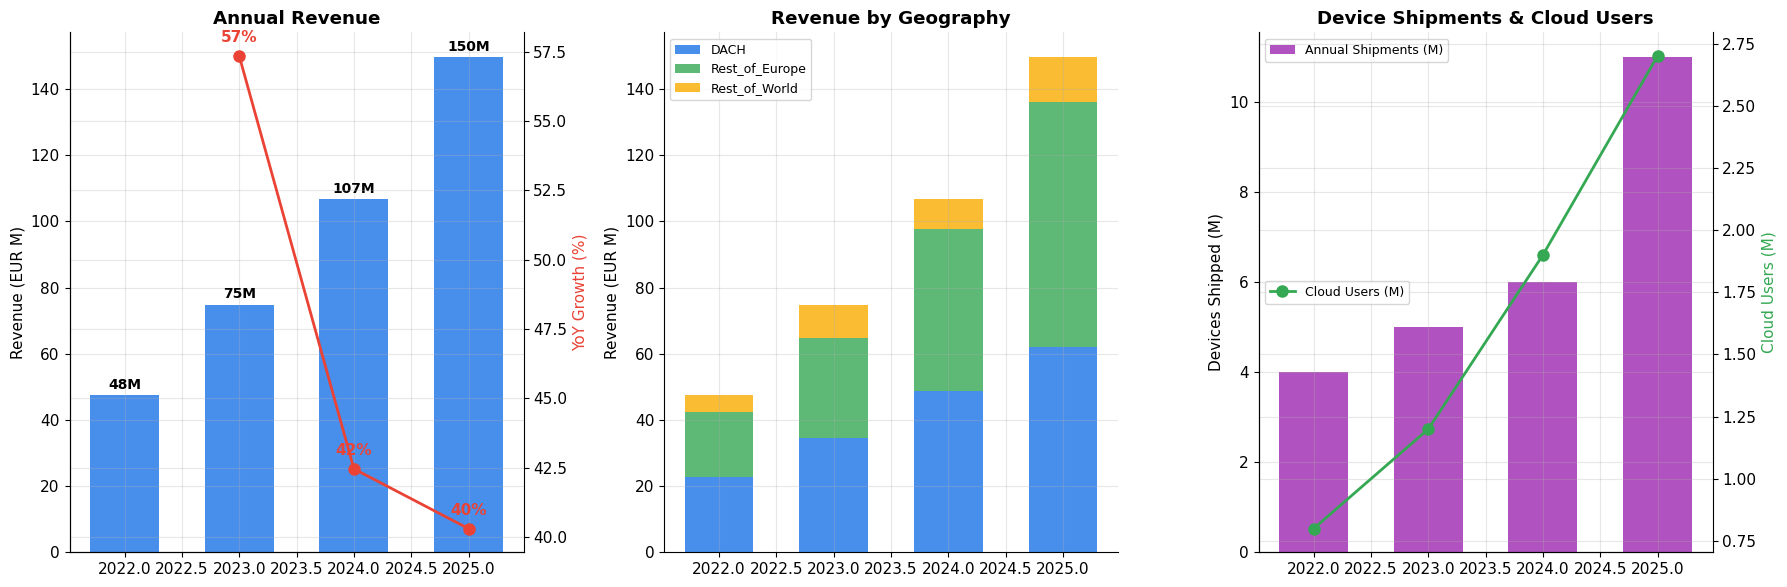

Historical revenue charts saved.


In [8]:
# ── Cell 9: Historical Revenue & Growth Charts ──────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Revenue bars with growth line
years = income_stmt.index
rev = income_stmt['Revenue'] / 1000  # EUR M
ax1 = axes[0]
bars = ax1.bar(years, rev, color=COLORS['primary'], alpha=0.8, width=0.6)
ax1.set_ylabel('Revenue (EUR M)')
ax1.set_title('Annual Revenue', fontweight='bold')
for bar, val in zip(bars, rev):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.0f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1b = ax1.twinx()
growth = income_stmt['Revenue'].pct_change() * 100
ax1b.plot(years[1:], growth.dropna(), 'o-', color=COLORS['accent'], linewidth=2, markersize=8)
ax1b.set_ylabel('YoY Growth (%)', color=COLORS['accent'])
ax1b.spines['right'].set_visible(True)
for yr, g in zip(years[1:], growth.dropna()):
    ax1b.annotate(f'{g:.0f}%', (yr, g), textcoords='offset points',
                  xytext=(0, 10), ha='center', color=COLORS['accent'], fontweight='bold')

# 2) Geographic mix stacked bars
ax2 = axes[1]
bottom = np.zeros(len(years))
colors_geo = [COLORS['primary'], COLORS['secondary'], COLORS['gold']]
for i, col in enumerate(['DACH', 'Rest_of_Europe', 'Rest_of_World']):
    vals = geo_data[col] / 1000
    ax2.bar(years, vals, bottom=bottom, color=colors_geo[i], alpha=0.8, label=col, width=0.6)
    bottom += vals.values
ax2.set_ylabel('Revenue (EUR M)')
ax2.set_title('Revenue by Geography', fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)

# 3) Device shipments and cloud users
ax3 = axes[2]
ax3.bar(years, kpi_data['Devices_Shipped_Annual_M'], color=COLORS['purple'], alpha=0.8, width=0.6, label='Annual Shipments (M)')
ax3.set_ylabel('Devices Shipped (M)')
ax3.set_title('Device Shipments & Cloud Users', fontweight='bold')
ax3b = ax3.twinx()
ax3b.plot(years, kpi_data['Cloud_Users_M'], 'o-', color=COLORS['secondary'], linewidth=2, markersize=8, label='Cloud Users (M)')
ax3b.set_ylabel('Cloud Users (M)', color=COLORS['secondary'])
ax3b.spines['right'].set_visible(True)
ax3.legend(loc='upper left', fontsize=9)
ax3b.legend(loc='center left', fontsize=9)

plt.tight_layout()
plt.savefig('/home/eyal/Downloads/financial analysis/SLYG/shely_hist_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Historical revenue charts saved.')

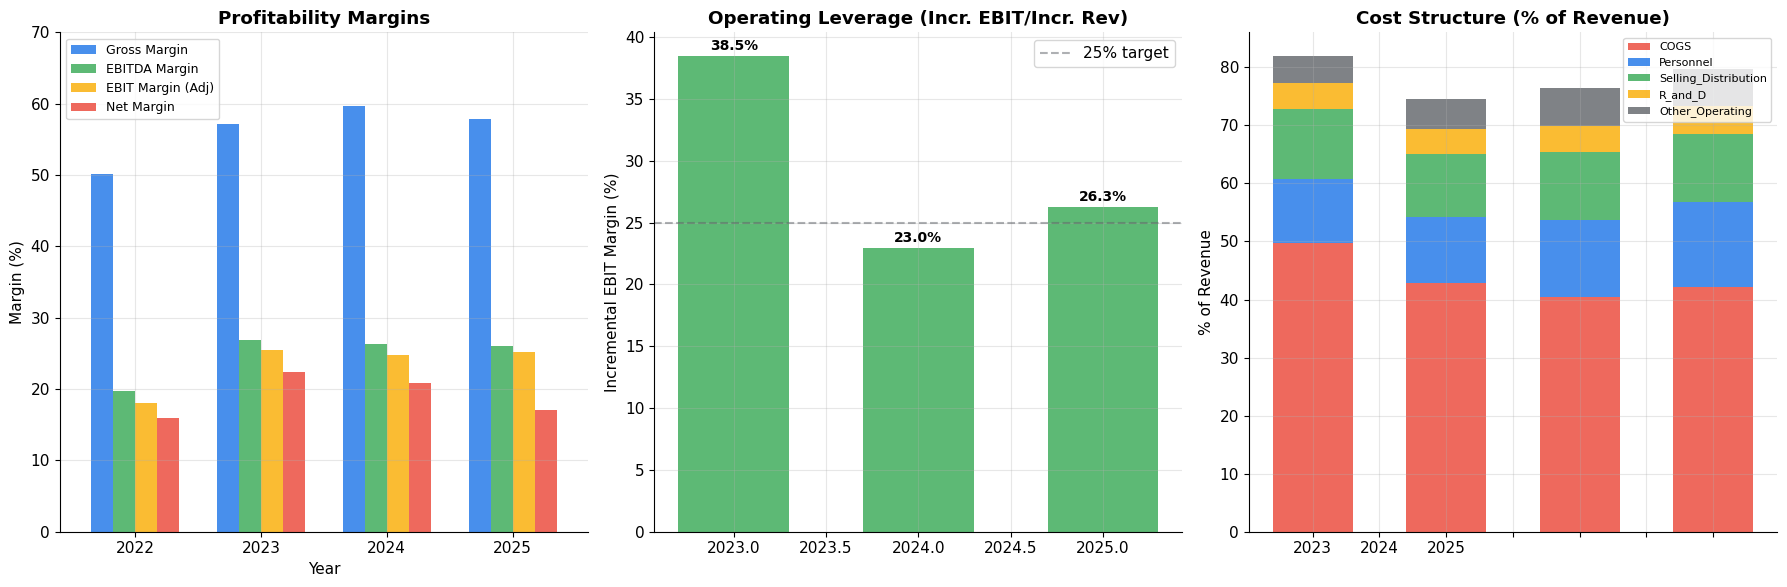

In [9]:
# ── Cell 10: Margin & Operating Leverage Charts ─────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Margin waterfall
ax1 = axes[0]
margins = pd.DataFrame({
    'Gross Margin': income_stmt['Gross_Margin'],
    'EBITDA Margin': income_stmt['EBITDA_Margin'],
    'EBIT Margin (Adj)': income_stmt['EBIT_Margin_Adj'],
    'Net Margin': income_stmt['Net_Margin'],
})
margins.plot(kind='bar', ax=ax1, color=[COLORS['primary'], COLORS['secondary'],
             COLORS['gold'], COLORS['accent']], alpha=0.8, width=0.7)
ax1.set_ylabel('Margin (%)')
ax1.set_title('Profitability Margins', fontweight='bold')
ax1.set_xticklabels(years, rotation=0)
ax1.legend(fontsize=9, loc='upper left')
ax1.set_ylim(0, 70)

# 2) Operating leverage — incremental EBIT margin
ax2 = axes[1]
incr_rev = income_stmt['Revenue'].diff()
incr_ebit = income_stmt['EBIT_Adjusted'].diff()
incr_margin = (incr_ebit / incr_rev * 100).dropna()
ax2.bar(years[1:], incr_margin, color=COLORS['secondary'], alpha=0.8, width=0.6)
ax2.axhline(y=25, color=COLORS['neutral'], linestyle='--', alpha=0.5, label='25% target')
ax2.set_ylabel('Incremental EBIT Margin (%)')
ax2.set_title('Operating Leverage (Incr. EBIT/Incr. Rev)', fontweight='bold')
for yr, m in zip(years[1:], incr_margin):
    ax2.text(yr, m + 0.5, f'{m:.1f}%', ha='center', fontweight='bold', fontsize=10)
ax2.legend()

# 3) Expense as % of revenue
ax3 = axes[2]
exp_cats = ['COGS', 'Personnel', 'Selling_Distribution', 'R_and_D', 'Other_Operating']
exp_colors = [COLORS['accent'], COLORS['primary'], COLORS['secondary'], COLORS['gold'], COLORS['neutral']]
bottom = np.zeros(len(years))
for cat, col in zip(exp_cats, exp_colors):
    vals = expense_pct[cat]
    ax3.bar(years, vals, bottom=bottom, color=col, alpha=0.8, label=cat, width=0.6)
    bottom += vals.values
ax3.set_ylabel('% of Revenue')
ax3.set_title('Cost Structure (% of Revenue)', fontweight='bold')
ax3.legend(fontsize=8, loc='upper right')
ax3.set_xticklabels(years, rotation=0)

plt.tight_layout()
plt.savefig('/home/eyal/Downloads/financial analysis/SLYG/shely_margins.png', dpi=150, bbox_inches='tight')
plt.show()

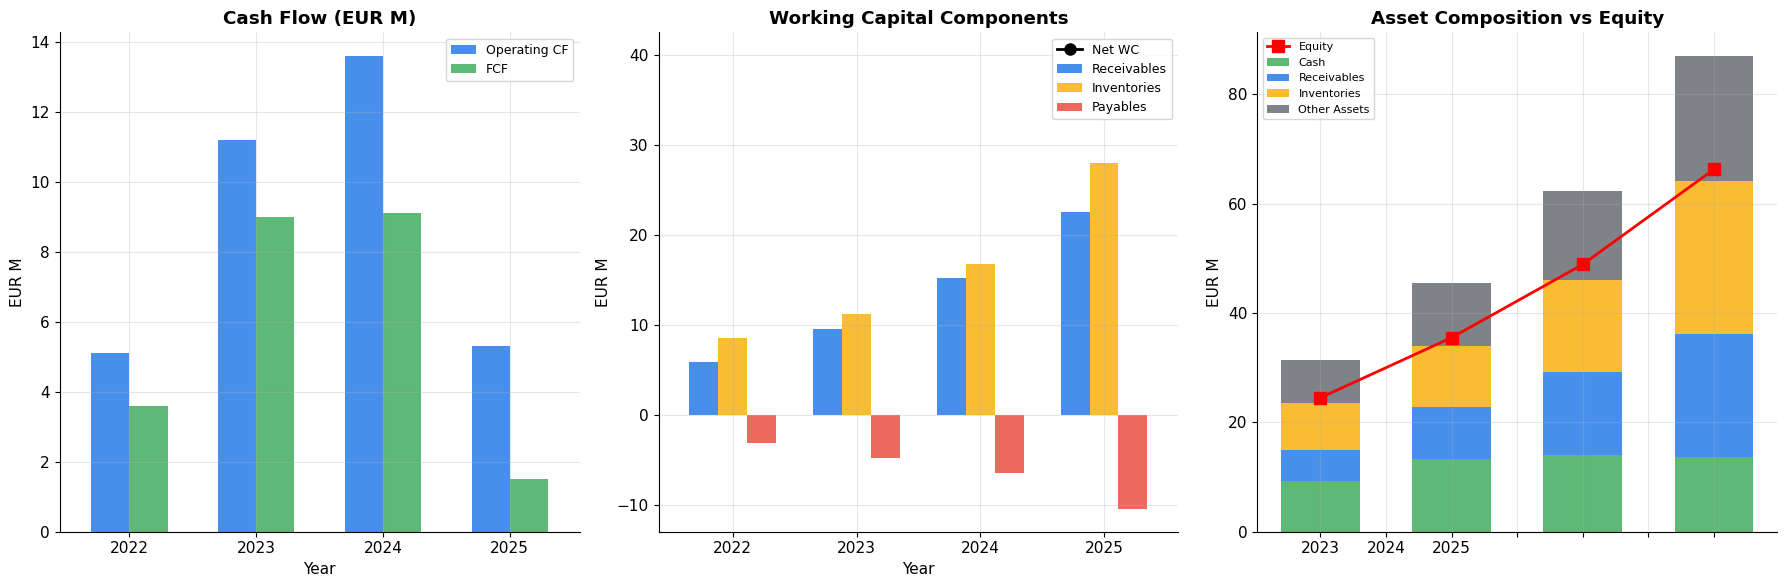

In [10]:
# ── Cell 11: Cash Flow & Balance Sheet Analysis ─────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Cash flow components
ax1 = axes[0]
cf_items = pd.DataFrame({
    'Operating CF': cash_flow['Operating_CF'] / 1000,
    'Investing CF': cash_flow['Investing_CF'] / 1000,
    'Financing CF': cash_flow['Financing_CF'] / 1000,
    'FCF': cash_flow['FCF'] / 1000,
}, index=years)
cf_items[['Operating CF', 'FCF']].plot(kind='bar', ax=ax1,
    color=[COLORS['primary'], COLORS['secondary']], alpha=0.8, width=0.6)
ax1.set_ylabel('EUR M')
ax1.set_title('Cash Flow (EUR M)', fontweight='bold')
ax1.set_xticklabels(years, rotation=0)
ax1.legend(fontsize=9)

# 2) Working capital build
ax2 = axes[1]
wc = pd.DataFrame({
    'Receivables': balance_sheet['Trade_Receivables'] / 1000,
    'Inventories': balance_sheet['Inventories'] / 1000,
    'Payables': -balance_sheet['Trade_Payables'] / 1000,
}, index=years)
wc['Net WC'] = wc['Receivables'] + wc['Inventories'] + wc['Payables']
colors_wc = [COLORS['primary'], COLORS['gold'], COLORS['accent']]
wc[['Receivables', 'Inventories', 'Payables']].plot(kind='bar', ax=ax2,
    color=colors_wc, alpha=0.8, width=0.7)
ax2.plot(years, wc['Net WC'], 'ko-', markersize=8, linewidth=2, label='Net WC')
ax2.set_ylabel('EUR M')
ax2.set_title('Working Capital Components', fontweight='bold')
ax2.set_xticklabels(years, rotation=0)
ax2.legend(fontsize=9)

# 3) Balance sheet composition
ax3 = axes[2]
bs_comp = pd.DataFrame({
    'Cash': balance_sheet['Cash_Equivalents'] / 1000,
    'Receivables': balance_sheet['Trade_Receivables'] / 1000,
    'Inventories': balance_sheet['Inventories'] / 1000,
    'Other Assets': (balance_sheet['Total_Assets'] - balance_sheet['Cash_Equivalents']
                     - balance_sheet['Trade_Receivables'] - balance_sheet['Inventories']) / 1000,
}, index=years)
bottom = np.zeros(len(years))
colors_bs = [COLORS['secondary'], COLORS['primary'], COLORS['gold'], COLORS['neutral']]
for col, c in zip(bs_comp.columns, colors_bs):
    ax3.bar(years, bs_comp[col], bottom=bottom, color=c, alpha=0.8, label=col, width=0.6)
    bottom += bs_comp[col].values
ax3.plot(years, balance_sheet['Total_Equity'] / 1000, 'rs-', markersize=8, linewidth=2, label='Equity')
ax3.set_ylabel('EUR M')
ax3.set_title('Asset Composition vs Equity', fontweight='bold')
ax3.legend(fontsize=8)
ax3.set_xticklabels(years, rotation=0)

plt.tight_layout()
plt.savefig('/home/eyal/Downloads/financial analysis/SLYG/shely_cashflow_bs.png', dpi=150, bbox_inches='tight')
plt.show()

# Cell Group 3: Bottom-Up Operating Model (2026-2030)

Three scenarios (Bull, Base, Bear) driven by:
- **Device shipment growth** — the master variable driving hardware revenue
- **Average selling price (ASP)** trends — product mix shift toward higher-value Gen4/Pro vs Mini
- **Cloud/subscription revenue** — emerging high-margin recurring stream
- **Geographic expansion** — DACH deceleration, Rest of Europe/World acceleration
- **Gross margin** — hardware margin trajectory plus software mix effect
- **Operating leverage** — OpEx scaling slower than revenue

In [11]:
# ── Cell 13: Bottom-Up Model Assumptions ─────────────────────

proj_years = [2026, 2027, 2028, 2029, 2030]

# Scenario assumptions dictionary
scenarios = {
    'Bull': {
        'device_growth':        [0.35, 0.28, 0.25, 0.22, 0.20],  # annual shipment growth
        'asp_eur':              [14.5, 15.0, 15.5, 16.0, 16.5],  # avg revenue per device
        'cloud_sub_rev_K':      [1_500, 3_500, 7_000, 12_000, 20_000],  # subscription rev EUR K
        'gross_margin_pct':     [58.0, 58.5, 59.0, 59.5, 60.0],
        'opex_pct_of_rev':      [33.0, 32.0, 31.0, 30.5, 30.0],
        'mgmt_sbc_K':           [5_000, 4_000, 3_000, 2_000, 1_000],
        'tax_rate':             0.10,
        'da_pct_rev':           0.018,
        'capex_pct_rev':        0.025,
        'nwc_pct_rev':          0.27,   # net working capital as % of rev
        'label': 'Bull',
    },
    'Base': {
        'device_growth':        [0.28, 0.22, 0.18, 0.17, 0.15],
        'asp_eur':              [14.2, 14.3, 14.5, 14.7, 14.9],
        'cloud_sub_rev_K':      [1_200, 2_500, 5_000, 8_500, 13_000],
        'gross_margin_pct':     [57.5, 57.5, 57.8, 58.0, 58.0],
        'opex_pct_of_rev':      [33.0, 32.5, 32.0, 31.5, 31.0],
        'mgmt_sbc_K':           [5_000, 4_000, 3_000, 2_500, 2_000],
        'tax_rate':             0.10,
        'da_pct_rev':           0.018,
        'capex_pct_rev':        0.025,
        'nwc_pct_rev':          0.28,
        'label': 'Base',
    },
    'Bear': {
        'device_growth':        [0.20, 0.15, 0.12, 0.10, 0.08],
        'asp_eur':              [13.5, 13.5, 13.5, 13.5, 13.5],
        'cloud_sub_rev_K':      [  800, 1_500, 2_500, 4_000, 6_000],
        'gross_margin_pct':     [56.5, 56.0, 55.5, 55.0, 55.0],
        'opex_pct_of_rev':      [34.0, 33.5, 33.0, 33.0, 33.0],
        'mgmt_sbc_K':           [6_000, 5_000, 4_000, 3_500, 3_000],
        'tax_rate':             0.10,
        'da_pct_rev':           0.020,
        'capex_pct_rev':        0.028,
        'nwc_pct_rev':          0.30,
        'label': 'Bear',
    },
}

# Print assumptions table
print('═' * 80)
print('SCENARIO ASSUMPTIONS')
print('═' * 80)
for name, s in scenarios.items():
    print(f'\n--- {name} Case ---')
    print(f'  Device shipment growth: {[f"{g*100:.0f}%" for g in s["device_growth"]]}')
    print(f'  ASP (EUR/device):       {s["asp_eur"]}')
    print(f'  Cloud sub rev (EUR K):  {s["cloud_sub_rev_K"]}')
    print(f'  Gross margin:           {s["gross_margin_pct"]}')
    print(f'  OpEx % of revenue:      {s["opex_pct_of_rev"]}')
    print(f'  Tax rate:               {s["tax_rate"]*100:.0f}%')
    print(f'  NWC % of revenue:       {s["nwc_pct_rev"]*100:.0f}%')

════════════════════════════════════════════════════════════════════════════════
SCENARIO ASSUMPTIONS
════════════════════════════════════════════════════════════════════════════════

--- Bull Case ---
  Device shipment growth: ['35%', '28%', '25%', '22%', '20%']
  ASP (EUR/device):       [14.5, 15.0, 15.5, 16.0, 16.5]
  Cloud sub rev (EUR K):  [1500, 3500, 7000, 12000, 20000]
  Gross margin:           [58.0, 58.5, 59.0, 59.5, 60.0]
  OpEx % of revenue:      [33.0, 32.0, 31.0, 30.5, 30.0]
  Tax rate:               10%
  NWC % of revenue:       27%

--- Base Case ---
  Device shipment growth: ['28%', '22%', '18%', '17%', '15%']
  ASP (EUR/device):       [14.2, 14.3, 14.5, 14.7, 14.9]
  Cloud sub rev (EUR K):  [1200, 2500, 5000, 8500, 13000]
  Gross margin:           [57.5, 57.5, 57.8, 58.0, 58.0]
  OpEx % of revenue:      [33.0, 32.5, 32.0, 31.5, 31.0]
  Tax rate:               10%
  NWC % of revenue:       28%

--- Bear Case ---
  Device shipment growth: ['20%', '15%', '12%', '10%', '8

In [12]:
# ── Cell 14: Build Projections for All Scenarios ────────────

def build_projections(scenario, base_devices_M=11.0, base_rev_K=149_700, base_nwc_K=40_000):
    """Build bottom-up revenue and earnings projections."""
    s = scenario
    results = []
    prev_devices = base_devices_M
    prev_nwc = base_nwc_K

    for i, yr in enumerate(proj_years):
        # Device shipments
        devices_M = prev_devices * (1 + s['device_growth'][i])
        # Hardware revenue
        hw_rev_K = devices_M * 1_000 * s['asp_eur'][i]  # devices(M) * 1000 * ASP = EUR K
        # Cloud/subscription revenue
        cloud_rev_K = s['cloud_sub_rev_K'][i]
        # Total revenue
        total_rev_K = hw_rev_K + cloud_rev_K

        # Gross profit (blended margin: hardware GM + near-100% cloud GM)
        hw_gm = s['gross_margin_pct'][i] / 100
        cloud_gm = 0.90  # cloud revenue ~90% gross margin
        gross_profit_K = hw_rev_K * hw_gm + cloud_rev_K * cloud_gm
        blended_gm = gross_profit_K / total_rev_K * 100

        # Operating expenses
        opex_K = total_rev_K * s['opex_pct_of_rev'][i] / 100
        mgmt_sbc_K = s['mgmt_sbc_K'][i]

        # EBIT
        ebit_adj_K = gross_profit_K - opex_K
        ebit_reported_K = ebit_adj_K - mgmt_sbc_K

        # D&A and EBITDA
        da_K = total_rev_K * s['da_pct_rev']
        ebitda_K = ebit_adj_K + da_K

        # Net income (using Bulgaria 10% tax rate)
        pretax_K = ebit_reported_K  # simplified: minimal net finance
        tax_K = pretax_K * s['tax_rate']
        net_income_K = pretax_K - tax_K

        # Capex
        capex_K = total_rev_K * s['capex_pct_rev']

        # Working capital
        nwc_K = total_rev_K * s['nwc_pct_rev']
        delta_nwc_K = nwc_K - prev_nwc

        # Free Cash Flow (NOPAT + D&A - Capex - Delta WC)
        nopat_K = ebit_adj_K * (1 - s['tax_rate'])
        fcf_K = nopat_K + da_K - capex_K - delta_nwc_K

        results.append({
            'Year': yr,
            'Devices_M': devices_M,
            'HW_Rev_K': hw_rev_K,
            'Cloud_Rev_K': cloud_rev_K,
            'Revenue_K': total_rev_K,
            'Rev_Growth_Pct': (total_rev_K / base_rev_K - 1) * 100 if i == 0 else None,
            'Gross_Profit_K': gross_profit_K,
            'Blended_GM_Pct': blended_gm,
            'OpEx_K': opex_K,
            'EBIT_Adj_K': ebit_adj_K,
            'EBIT_Margin_Adj_Pct': ebit_adj_K / total_rev_K * 100,
            'EBIT_Reported_K': ebit_reported_K,
            'EBITDA_K': ebitda_K,
            'DA_K': da_K,
            'Net_Income_K': net_income_K,
            'Capex_K': capex_K,
            'NWC_K': nwc_K,
            'Delta_NWC_K': delta_nwc_K,
            'NOPAT_K': nopat_K,
            'FCF_K': fcf_K,
            'FCF_Margin_Pct': fcf_K / total_rev_K * 100,
        })
        prev_devices = devices_M
        prev_nwc = nwc_K
        base_rev_K = total_rev_K  # for growth calc

    df = pd.DataFrame(results).set_index('Year')
    # Fix growth calculation
    rev_series = pd.concat([pd.Series([149_700], index=[2025]), df['Revenue_K']])
    df['Rev_Growth_Pct'] = rev_series.pct_change().iloc[1:].values * 100
    return df

# Build all scenarios
projections = {}
for name, s in scenarios.items():
    projections[name] = build_projections(s)

# Display Base case
print('═' * 80)
print('BASE CASE PROJECTIONS (EUR K)')
print('═' * 80)
base = projections['Base']
display_proj = ['Revenue_K', 'Rev_Growth_Pct', 'Blended_GM_Pct', 'EBIT_Adj_K',
                'EBIT_Margin_Adj_Pct', 'Net_Income_K', 'FCF_K', 'FCF_Margin_Pct', 'Devices_M']
print(base[display_proj].T.to_string(float_format=lambda x: f'{x:,.1f}'))

# Show all scenarios revenue comparison
print('\n' + '═' * 60)
print('REVENUE COMPARISON ACROSS SCENARIOS (EUR M)')
print('═' * 60)
for name in ['Bull', 'Base', 'Bear']:
    rev_M = projections[name]['Revenue_K'] / 1000
    print(f'  {name:5s}: ' + '  '.join([f'{yr}: {v:,.0f}M' for yr, v in rev_M.items()]))

════════════════════════════════════════════════════════════════════════════════
BASE CASE PROJECTIONS (EUR K)
════════════════════════════════════════════════════════════════════════════════
Year                     2026      2027      2028      2029      2030
Revenue_K           201,136.0 248,139.7 298,908.7 357,116.3 419,363.3
Rev_Growth_Pct           34.4      23.4      20.5      19.5      17.4
Blended_GM_Pct           57.7      57.8      58.3      58.8      59.0
EBIT_Adj_K           49,668.3  62,847.4  78,728.5  97,355.8 117,388.1
EBIT_Margin_Adj_Pct      24.7      25.3      26.3      27.3      28.0
Net_Income_K         40,201.5  52,962.7  68,155.6  85,370.2 103,849.3
FCF_K                26,975.5  41,664.7  54,547.9  68,822.3  85,284.6
FCF_Margin_Pct           13.4      16.8      18.2      19.3      20.3
Devices_M                14.1      17.2      20.3      23.7      27.3

════════════════════════════════════════════════════════════
REVENUE COMPARISON ACROSS SCENARIOS (EUR M)
══

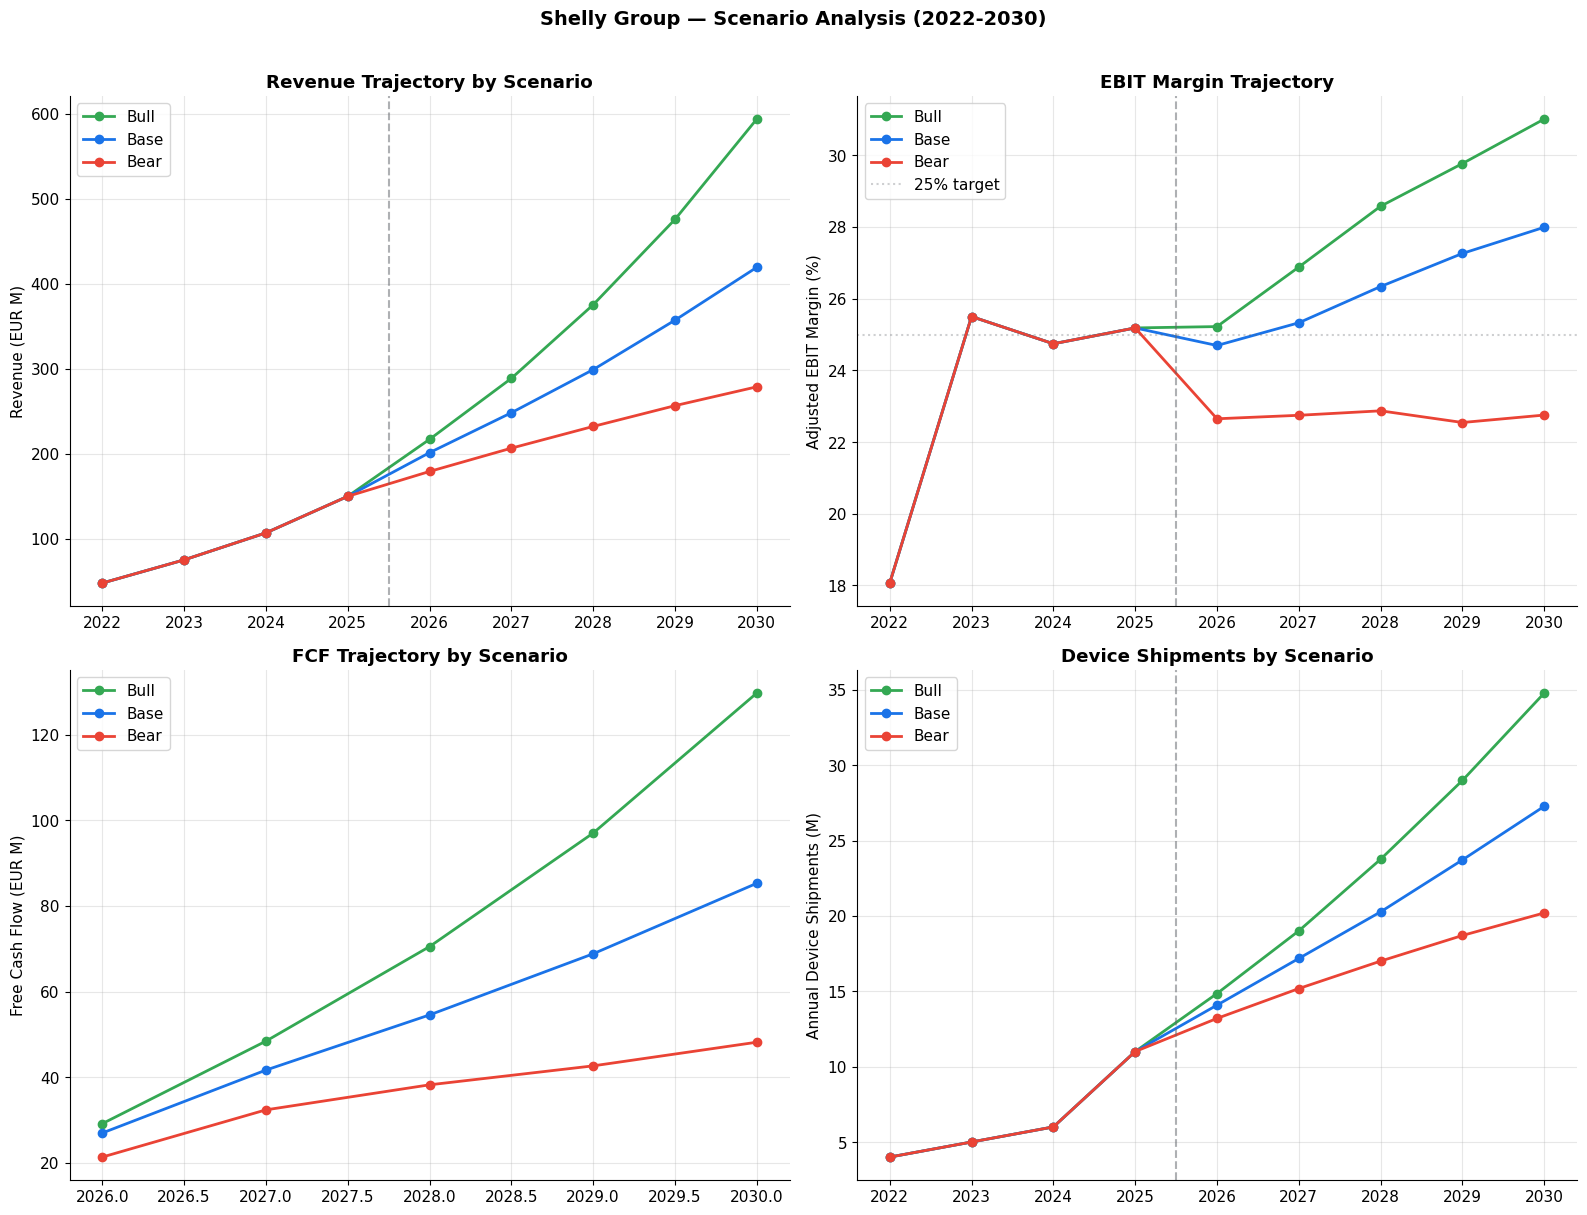

In [13]:
# ── Cell 15: Scenario Comparison Charts ──────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
scenario_colors = {'Bull': COLORS['secondary'], 'Base': COLORS['primary'], 'Bear': COLORS['accent']}

# 1) Revenue trajectory
ax = axes[0, 0]
# Add historical
hist_rev = income_stmt['Revenue'] / 1000
for name, proj in projections.items():
    combined = pd.concat([hist_rev, proj['Revenue_K'] / 1000])
    ax.plot(combined.index, combined.values, 'o-', color=scenario_colors[name],
            linewidth=2, markersize=6, label=name)
ax.axvline(x=2025.5, color=COLORS['neutral'], linestyle='--', alpha=0.5)
ax.set_ylabel('Revenue (EUR M)')
ax.set_title('Revenue Trajectory by Scenario', fontweight='bold')
ax.legend()

# 2) EBIT margin
ax = axes[0, 1]
hist_ebit_m = income_stmt['EBIT_Margin_Adj']
for name, proj in projections.items():
    combined = pd.concat([hist_ebit_m, proj['EBIT_Margin_Adj_Pct']])
    ax.plot(combined.index, combined.values, 'o-', color=scenario_colors[name],
            linewidth=2, markersize=6, label=name)
ax.axvline(x=2025.5, color=COLORS['neutral'], linestyle='--', alpha=0.5)
ax.axhline(y=25, color=COLORS['neutral'], linestyle=':', alpha=0.3, label='25% target')
ax.set_ylabel('Adjusted EBIT Margin (%)')
ax.set_title('EBIT Margin Trajectory', fontweight='bold')
ax.legend()

# 3) FCF
ax = axes[1, 0]
for name, proj in projections.items():
    ax.plot(proj_years, proj['FCF_K'] / 1000, 'o-', color=scenario_colors[name],
            linewidth=2, markersize=6, label=name)
ax.set_ylabel('Free Cash Flow (EUR M)')
ax.set_title('FCF Trajectory by Scenario', fontweight='bold')
ax.legend()

# 4) Device shipments
ax = axes[1, 1]
hist_dev = kpi_data['Devices_Shipped_Annual_M']
for name, proj in projections.items():
    combined = pd.concat([hist_dev, proj['Devices_M']])
    ax.plot(combined.index, combined.values, 'o-', color=scenario_colors[name],
            linewidth=2, markersize=6, label=name)
ax.axvline(x=2025.5, color=COLORS['neutral'], linestyle='--', alpha=0.5)
ax.set_ylabel('Annual Device Shipments (M)')
ax.set_title('Device Shipments by Scenario', fontweight='bold')
ax.legend()

plt.suptitle('Shelly Group — Scenario Analysis (2022-2030)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/home/eyal/Downloads/financial analysis/SLYG/shely_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Cell 16: Product/Geographic Growth Matrix ───────────────

print('═' * 80)
print('GEOGRAPHIC REVENUE GROWTH MATRIX — BASE CASE (EUR M)')
print('═' * 80)

# Project geographic breakdown for Base case
# Assumptions: DACH growth decelerates (20%->12%), Rest Europe accelerates then moderates,
# Rest of World (incl US) grows fastest
geo_growth = {
    'DACH':           [0.20, 0.18, 0.16, 0.14, 0.12],
    'Rest_of_Europe': [0.35, 0.32, 0.28, 0.25, 0.22],
    'Rest_of_World':  [0.50, 0.45, 0.40, 0.35, 0.30],
}

geo_proj = pd.DataFrame(index=proj_years)
base_geo = {'DACH': 62_000, 'Rest_of_Europe': 74_000, 'Rest_of_World': 13_700}

for region in ['DACH', 'Rest_of_Europe', 'Rest_of_World']:
    vals = []
    prev = base_geo[region]
    for i, yr in enumerate(proj_years):
        val = prev * (1 + geo_growth[region][i])
        vals.append(val)
        prev = val
    geo_proj[region] = vals

geo_proj['Total'] = geo_proj.sum(axis=1)
geo_proj_M = geo_proj / 1000

# Print table
print(geo_proj_M.to_string(float_format=lambda x: f'{x:.1f}'))
print()

# Mix evolution
geo_mix = geo_proj[['DACH', 'Rest_of_Europe', 'Rest_of_World']].div(geo_proj['Total'], axis=0) * 100
print('GEOGRAPHIC MIX (%) — BASE CASE')
print(geo_mix.to_string(float_format=lambda x: f'{x:.1f}%'))
print()

# Cloud/subscription as % of total revenue
print('CLOUD/SUBSCRIPTION REVENUE AS % OF TOTAL — ALL SCENARIOS')
for name in ['Bull', 'Base', 'Bear']:
    pct = projections[name]['Cloud_Rev_K'] / projections[name]['Revenue_K'] * 100
    print(f'  {name:5s}: ' + '  '.join([f'{yr}: {v:.1f}%' for yr, v in pct.items()]))

════════════════════════════════════════════════════════════════════════════════
GEOGRAPHIC REVENUE GROWTH MATRIX — BASE CASE (EUR M)
════════════════════════════════════════════════════════════════════════════════
      DACH  Rest_of_Europe  Rest_of_World  Total
2026  74.4            99.9           20.6  194.8
2027  87.8           131.9           29.8  249.5
2028 101.8           168.8           41.7  312.3
2029 116.1           211.0           56.3  383.4
2030 130.0           257.4           73.2  460.6

GEOGRAPHIC MIX (%) — BASE CASE
      DACH  Rest_of_Europe  Rest_of_World
2026 38.2%           51.3%          10.5%
2027 35.2%           52.9%          11.9%
2028 32.6%           54.0%          13.4%
2029 30.3%           55.0%          14.7%
2030 28.2%           55.9%          15.9%

CLOUD/SUBSCRIPTION REVENUE AS % OF TOTAL — ALL SCENARIOS
  Bull : 2026: 0.7%  2027: 1.2%  2028: 1.9%  2029: 2.5%  2030: 3.4%
  Base : 2026: 0.6%  2027: 1.0%  2028: 1.7%  2029: 2.4%  2030: 3.1%
  Bear : 2026

# Cell Group 4: 3-Statement Projected Model (2026-2030)

Full income statement, balance sheet, and cash flow projections for the Base case.
Cross-checked with Bull and Bear scenarios for key metrics.

In [15]:
# ── Cell 18: 3-Statement Projected Model (Base Case) ────────

base_proj = projections['Base']

# --- Projected Income Statement ---
proj_is = pd.DataFrame(index=proj_years)
proj_is['Revenue'] = base_proj['Revenue_K']
proj_is['COGS'] = base_proj['Revenue_K'] - base_proj['Gross_Profit_K']
proj_is['Gross_Profit'] = base_proj['Gross_Profit_K']
proj_is['Gross_Margin_%'] = base_proj['Blended_GM_Pct']
proj_is['OpEx'] = base_proj['OpEx_K']
proj_is['Mgmt_SBC'] = [5_000, 4_000, 3_000, 2_500, 2_000]
proj_is['EBIT_Adj'] = base_proj['EBIT_Adj_K']
proj_is['EBIT_Reported'] = base_proj['EBIT_Reported_K']
proj_is['EBIT_Margin_Adj_%'] = base_proj['EBIT_Margin_Adj_Pct']
proj_is['D_and_A'] = base_proj['DA_K']
proj_is['EBITDA'] = base_proj['EBITDA_K']
proj_is['Tax_10pct'] = base_proj['EBIT_Reported_K'] * 0.10
proj_is['Net_Income'] = base_proj['Net_Income_K']
proj_is['EPS'] = base_proj['Net_Income_K'] / 18_900  # diluted shares ~18.9M

print('═' * 80)
print('PROJECTED INCOME STATEMENT — BASE CASE (EUR K)')
print('═' * 80)
print(proj_is.T.to_string(float_format=lambda x: f'{x:,.1f}'))

# --- Projected Balance Sheet ---
proj_bs = pd.DataFrame(index=proj_years)
prev_cash = 13_600
prev_equity = 66_300

for i, yr in enumerate(proj_years):
    rev = base_proj.loc[yr, 'Revenue_K']
    ni = base_proj.loc[yr, 'Net_Income_K']
    capex = base_proj.loc[yr, 'Capex_K']
    nwc = base_proj.loc[yr, 'NWC_K']
    da = base_proj.loc[yr, 'DA_K']
    ocf = ni + da + scenarios['Base']['mgmt_sbc_K'][i] - base_proj.loc[yr, 'Delta_NWC_K']
    div = min(ni * 0.10, 5_000)  # ~10% payout ratio, capped
    fcf_bs = ocf - capex
    cash = prev_cash + fcf_bs - div

    proj_bs.loc[yr, 'Cash'] = cash
    proj_bs.loc[yr, 'Receivables'] = rev * 0.15  # ~55 days
    proj_bs.loc[yr, 'Inventories'] = rev * 0.17
    proj_bs.loc[yr, 'Other_Current'] = rev * 0.03
    proj_bs.loc[yr, 'Total_Current'] = cash + rev * 0.35
    proj_bs.loc[yr, 'PP_E'] = 7_200 + capex * (i + 1) - da * (i + 1) * 0.5
    proj_bs.loc[yr, 'Intangibles'] = 6_500 + 1_500 * (i + 1)
    proj_bs.loc[yr, 'Total_Assets'] = proj_bs.loc[yr, 'Total_Current'] + proj_bs.loc[yr, 'PP_E'] + proj_bs.loc[yr, 'Intangibles'] + 5_000
    proj_bs.loc[yr, 'Total_Liabilities'] = rev * 0.14
    proj_bs.loc[yr, 'Equity'] = prev_equity + ni - div + scenarios['Base']['mgmt_sbc_K'][i]
    proj_bs.loc[yr, 'Equity_Ratio_%'] = proj_bs.loc[yr, 'Equity'] / proj_bs.loc[yr, 'Total_Assets'] * 100

    prev_cash = cash
    prev_equity = proj_bs.loc[yr, 'Equity']

print('\n' + '═' * 80)
print('PROJECTED BALANCE SHEET — BASE CASE (EUR K)')
print('═' * 80)
print(proj_bs.T.to_string(float_format=lambda x: f'{x:,.1f}'))

════════════════════════════════════════════════════════════════════════════════
PROJECTED INCOME STATEMENT — BASE CASE (EUR K)
════════════════════════════════════════════════════════════════════════════════
                       2026      2027      2028      2029      2030
Revenue           201,136.0 248,139.7 298,908.7 357,116.3 419,363.3
COGS               85,092.8 104,646.9 124,529.5 147,268.8 171,972.6
Gross_Profit      116,043.2 143,492.8 174,379.2 209,847.5 247,390.7
Gross_Margin_%         57.7      57.8      58.3      58.8      59.0
OpEx               66,374.9  80,645.4  95,650.8 112,491.6 130,002.6
Mgmt_SBC            5,000.0   4,000.0   3,000.0   2,500.0   2,000.0
EBIT_Adj           49,668.3  62,847.4  78,728.5  97,355.8 117,388.1
EBIT_Reported      44,668.3  58,847.4  75,728.5  94,855.8 115,388.1
EBIT_Margin_Adj_%      24.7      25.3      26.3      27.3      28.0
D_and_A             3,620.4   4,466.5   5,380.4   6,428.1   7,548.5
EBITDA             53,288.8  67,313.9  84,1

In [16]:
# ── Cell 19: Balance Sheet & Cash Flow Verification ─────────

# Projected Cash Flow Statement
proj_cf = pd.DataFrame(index=proj_years)
proj_cf['Net_Income'] = base_proj['Net_Income_K']
proj_cf['D_and_A'] = base_proj['DA_K']
proj_cf['SBC_NonCash'] = [5_000, 4_000, 3_000, 2_500, 2_000]
proj_cf['Delta_WC'] = -base_proj['Delta_NWC_K']
proj_cf['Operating_CF'] = proj_cf['Net_Income'] + proj_cf['D_and_A'] + proj_cf['SBC_NonCash'] + proj_cf['Delta_WC']
proj_cf['Capex'] = -base_proj['Capex_K']
proj_cf['FCF'] = proj_cf['Operating_CF'] + proj_cf['Capex']
proj_cf['Dividends'] = [-min(ni * 0.10, 5_000) for ni in base_proj['Net_Income_K']]
proj_cf['Net_Cash_Change'] = proj_cf['FCF'] + proj_cf['Dividends']

print('═' * 80)
print('PROJECTED CASH FLOW STATEMENT — BASE CASE (EUR K)')
print('═' * 80)
print(proj_cf.T.to_string(float_format=lambda x: f'{x:,.1f}'))

# Verification
print('\n' + '═' * 60)
print('VERIFICATION CHECKS')
print('═' * 60)
for yr in proj_years:
    rev = base_proj.loc[yr, 'Revenue_K']
    ebit = base_proj.loc[yr, 'EBIT_Adj_K']
    ni = base_proj.loc[yr, 'Net_Income_K']
    gm = base_proj.loc[yr, 'Blended_GM_Pct']
    em = base_proj.loc[yr, 'EBIT_Margin_Adj_Pct']
    print(f'  {yr}: Rev={rev/1000:,.0f}M  GM={gm:.1f}%  EBIT_m={em:.1f}%  NI={ni/1000:,.1f}M  '
          f'FCF={proj_cf.loc[yr, "FCF"]/1000:,.1f}M')

# Cumulative FCF
cum_fcf = proj_cf['FCF'].cumsum()
print(f'\n  Cumulative FCF (2026-2030): EUR {cum_fcf.iloc[-1]/1000:,.1f}M')
print(f'  Ending Cash (2030): EUR {proj_bs.loc[2030, "Cash"]/1000:,.1f}M')
print(f'  Ending Equity (2030): EUR {proj_bs.loc[2030, "Equity"]/1000:,.1f}M')

════════════════════════════════════════════════════════════════════════════════
PROJECTED CASH FLOW STATEMENT — BASE CASE (EUR K)
════════════════════════════════════════════════════════════════════════════════
                     2026      2027      2028      2029      2030
Net_Income       40,201.5  52,962.7  68,155.6  85,370.2 103,849.3
D_and_A           3,620.4   4,466.5   5,380.4   6,428.1   7,548.5
SBC_NonCash       5,000.0   4,000.0   3,000.0   2,500.0   2,000.0
Delta_WC        -16,318.1 -13,161.0 -14,215.3 -16,298.1 -17,429.2
Operating_CF     32,503.9  48,268.2  62,320.6  78,000.2  95,968.7
Capex            -5,028.4  -6,203.5  -7,472.7  -8,927.9 -10,484.1
FCF              27,475.5  42,064.7  54,847.9  69,072.3  85,484.6
Dividends        -4,020.1  -5,000.0  -5,000.0  -5,000.0  -5,000.0
Net_Cash_Change  23,455.3  37,064.7  49,847.9  64,072.3  80,484.6

════════════════════════════════════════════════════════════
VERIFICATION CHECKS
══════════════════════════════════════════════

# Cell Group 5: DCF Valuation

Discounted Cash Flow valuation using unlevered free cash flow (NOPAT + D&A - Capex - Delta WC).

Key parameters:
- **WACC**: 10.0% (CAPM with small-cap premium; no debt adjustment needed — net cash position)
- **Terminal Growth**: 3.0% (long-term nominal GDP; smart home is structural growth)
- **Tax Rate**: 10% (Bulgarian statutory rate)
- **Shares Outstanding**: 18.9M (diluted for management share program)

In [17]:
# ── Cell 21: DCF Valuation Function & Execution ─────────────

def dcf_valuation(proj_df, wacc=0.10, terminal_growth=0.03, net_cash_K=13_600,
                  diluted_shares_M=18.9, label=''):
    """
    Compute DCF valuation from projected FCF.
    Returns dict with key valuation metrics.
    """
    fcf = proj_df['FCF_K'].values
    years_out = np.arange(1, len(fcf) + 1)

    # Discount factors
    discount_factors = (1 + wacc) ** years_out

    # PV of projected FCFs
    pv_fcfs = fcf / discount_factors

    pv_fcf_total = pv_fcfs.sum()

    # Terminal value (Gordon Growth)
    terminal_fcf = fcf[-1] * (1 + terminal_growth)
    terminal_value = terminal_fcf / (wacc - terminal_growth)
    pv_terminal = terminal_value / discount_factors[-1]

    # Enterprise value
    ev = pv_fcf_total + pv_terminal

    # Equity value
    equity_value = ev + net_cash_K

    # Per share
    price_per_share = equity_value / (diluted_shares_M * 1000)

    result = {
        'label': label,
        'PV_FCFs_K': pv_fcf_total,
        'Terminal_Value_K': terminal_value,
        'PV_Terminal_K': pv_terminal,
        'TV_Pct_of_EV': pv_terminal / ev * 100,
        'Enterprise_Value_K': ev,
        'Net_Cash_K': net_cash_K,
        'Equity_Value_K': equity_value,
        'Diluted_Shares_M': diluted_shares_M,
        'Implied_Price': price_per_share,
        'WACC': wacc,
        'Terminal_Growth': terminal_growth,
    }
    return result

# Run DCF for all scenarios
print('═' * 80)
print('DCF VALUATION — ALL SCENARIOS')
print('═' * 80)

dcf_results = {}
for name, proj in projections.items():
    dcf = dcf_valuation(proj, label=name)
    dcf_results[name] = dcf
    print(f'\n--- {name} Case ---')
    print(f'  PV of FCFs (2026-2030):   EUR {dcf["PV_FCFs_K"]/1000:,.1f}M')
    print(f'  PV of Terminal Value:      EUR {dcf["PV_Terminal_K"]/1000:,.1f}M')
    print(f'  Terminal Value % of EV:    {dcf["TV_Pct_of_EV"]:.1f}%')
    print(f'  Enterprise Value:          EUR {dcf["Enterprise_Value_K"]/1000:,.1f}M')
    print(f'  + Net Cash:                EUR {dcf["Net_Cash_K"]/1000:,.1f}M')
    print(f'  = Equity Value:            EUR {dcf["Equity_Value_K"]/1000:,.1f}M')
    print(f'  Diluted Shares:            {dcf["Diluted_Shares_M"]:.1f}M')
    print(f'  *** Implied Price:         EUR {dcf["Implied_Price"]:.2f} ***')

# Current price comparison
current_price = 57.60
print(f'\n{"═" * 60}')
print(f'Current Price: EUR {current_price:.2f}')
print(f'{"═" * 60}')
for name in ['Bull', 'Base', 'Bear']:
    implied = dcf_results[name]['Implied_Price']
    upside = (implied / current_price - 1) * 100
    print(f'  {name:5s} Implied: EUR {implied:7.2f}  |  Upside: {upside:+.1f}%')

════════════════════════════════════════════════════════════════════════════════
DCF VALUATION — ALL SCENARIOS
════════════════════════════════════════════════════════════════════════════════

--- Bull Case ---
  PV of FCFs (2026-2030):   EUR 266.3M
  PV of Terminal Value:      EUR 1,185.1M
  Terminal Value % of EV:    81.7%
  Enterprise Value:          EUR 1,451.3M
  + Net Cash:                EUR 13.6M
  = Equity Value:            EUR 1,464.9M
  Diluted Shares:            18.9M
  *** Implied Price:         EUR 77.51 ***

--- Base Case ---
  PV of FCFs (2026-2030):   EUR 199.9M
  PV of Terminal Value:      EUR 779.2M
  Terminal Value % of EV:    79.6%
  Enterprise Value:          EUR 979.1M
  + Net Cash:                EUR 13.6M
  = Equity Value:            EUR 992.7M
  Diluted Shares:            18.9M
  *** Implied Price:         EUR 52.52 ***

--- Bear Case ---
  PV of FCFs (2026-2030):   EUR 133.9M
  PV of Terminal Value:      EUR 440.2M
  Terminal Value % of EV:    76.7%
  Enterpr

# Cell Group 6: Sensitivity Analysis & Output

WACC vs. terminal growth sensitivity, exit multiple cross-checks, scenario comparison, and peer benchmarking.

In [18]:
# ── Cell 23: Sensitivity Analysis (WACC vs Terminal Growth) ──

wacc_range = [0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14]
tg_range = [0.02, 0.025, 0.03, 0.035, 0.04]

# Base case sensitivity
base_fcf = projections['Base']['FCF_K'].values

sensitivity = pd.DataFrame(index=[f'{w*100:.0f}%' for w in wacc_range],
                            columns=[f'{tg*100:.1f}%' for tg in tg_range])

for w_idx, wacc in enumerate(wacc_range):
    for tg_idx, tg in enumerate(tg_range):
        dcf = dcf_valuation(projections['Base'], wacc=wacc, terminal_growth=tg)
        sensitivity.iloc[w_idx, tg_idx] = f'{dcf["Implied_Price"]:.2f}'

print('═' * 80)
print('PRICE SENSITIVITY — BASE CASE (EUR per share)')
print('Rows: WACC | Columns: Terminal Growth Rate')
print('═' * 80)
print(sensitivity.to_string())

# Highlight current price
print(f'\nCurrent Price: EUR {current_price:.2f}')
print(f'Base Case (10% WACC, 3.0% TG): EUR {dcf_results["Base"]["Implied_Price"]:.2f}')

# Exit multiple cross-check
print('\n' + '═' * 80)
print('EXIT MULTIPLE CROSS-CHECK (2030E, discounted to present at 10% WACC)')
print('═' * 80)

discount_5yr = (1.10) ** 5
ebit_multiples = [15, 20, 25, 30]
pe_multiples = [20, 25, 30, 35]

print('\nEV/EBIT Exit Multiple:')
header = f'{"EV/EBIT":>10s}'
for name in ['Bull', 'Base', 'Bear']:
    header += f'  {name:>10s}'
print(header)
for mult in ebit_multiples:
    row = f'{mult:>10d}x'
    for name in ['Bull', 'Base', 'Bear']:
        ebit_2030 = projections[name].loc[2030, 'EBIT_Adj_K']
        ev = ebit_2030 * mult + 13_600  # + net cash
        eq = ev / (18.9 * 1000)
        pv = eq / discount_5yr
        row += f'  EUR {pv:>6.2f}'
    print(row)

print('\nP/E Exit Multiple:')
header = f'{"P/E":>10s}'
for name in ['Bull', 'Base', 'Bear']:
    header += f'  {name:>10s}'
print(header)
for mult in pe_multiples:
    row = f'{mult:>10d}x'
    for name in ['Bull', 'Base', 'Bear']:
        ni_2030 = projections[name].loc[2030, 'Net_Income_K']
        eq = ni_2030 * mult / (18.9 * 1000)
        pv = eq / discount_5yr
        row += f'  EUR {pv:>6.2f}'
    print(row)

════════════════════════════════════════════════════════════════════════════════
PRICE SENSITIVITY — BASE CASE (EUR per share)
Rows: WACC | Columns: Terminal Growth Rate
════════════════════════════════════════════════════════════════════════════════
      2.0%   2.5%   3.0%   3.5%   4.0%
8%   64.18  69.20  75.23  82.60  91.82
9%   54.36  57.87  61.97  66.81  72.63
10%  47.02  49.59  52.52  55.91  59.86
11%  41.33  43.27  45.46  47.94  50.77
12%  36.80  38.31  39.98  41.86  43.97
13%  33.10  34.30  35.62  37.07  38.69
14%  30.04  31.00  32.06  33.22  34.49

Current Price: EUR 57.60
Base Case (10% WACC, 3.0% TG): EUR 52.52

════════════════════════════════════════════════════════════════════════════════
EXIT MULTIPLE CROSS-CHECK (2030E, discounted to present at 10% WACC)
════════════════════════════════════════════════════════════════════════════════

EV/EBIT Exit Multiple:
   EV/EBIT        Bull        Base        Bear
        15x  EUR  91.21  EUR  58.30  EUR  31.69
        20x  EUR 12

In [19]:
# ── Cell 24: Scenario Summary & Peer Comparison ─────────────

print('=' * 80)
print('SCENARIO SUMMARY')
print('=' * 80)

summary_data = []
for name in ['Bull', 'Base', 'Bear']:
    proj = projections[name]
    dcf = dcf_results[name]
    summary_data.append({
        'Scenario': name,
        'Rev_2026_M': proj.loc[2026, 'Revenue_K'] / 1000,
        'Rev_2030_M': proj.loc[2030, 'Revenue_K'] / 1000,
        'Rev_CAGR_25_30': ((proj.loc[2030, 'Revenue_K'] / 149_700) ** (1/5) - 1) * 100,
        'EBIT_2030_M': proj.loc[2030, 'EBIT_Adj_K'] / 1000,
        'EBIT_Margin_2030': proj.loc[2030, 'EBIT_Margin_Adj_Pct'],
        'NI_2030_M': proj.loc[2030, 'Net_Income_K'] / 1000,
        'Devices_2030_M': proj.loc[2030, 'Devices_M'],
        'FCF_2030_M': proj.loc[2030, 'FCF_K'] / 1000,
        'DCF_Price': dcf['Implied_Price'],
        'Upside_Pct': (dcf['Implied_Price'] / current_price - 1) * 100,
    })

summary_df = pd.DataFrame(summary_data).set_index('Scenario')
print(summary_df.T.to_string(float_format=lambda x: f'{x:,.1f}'))

# Peer comparison
print('\n' + '=' * 80)
print('PEER COMPARISON')
print('=' * 80)

peers = pd.DataFrame({
    'Company': ['Shelly Group', 'Tuya Smart', 'Legrand', 'Schneider Elec.', 'Assa Abloy'],
    'Ticker': ['SLYG', 'TUYA', 'LR.PA', 'SU.PA', 'ASSA-B.ST'],
    'Mkt_Cap_B': [1.04, 1.27, 26.0, 130.0, 35.0],
    'LTM_Rev_M': [150, 322, 8600, 36000, 14800],
    'Rev_Growth': ['40%', '8%', '3%', '6%', '4%'],
    'Gross_Margin': ['58%', '47%', '52%', '42%', '42%'],
    'EBIT_Margin': ['25%', '18%', '17%', '17%', '15%'],
    'EV_Sales': ['6.9x', '3.9x', '3.0x', '3.6x', '3.6x'],
    'EV_EBIT': ['27x', '22x', '18x', '21x', '24x'],
    'PE': ['42x', '22x', '24x', '28x', '28x'],
    'Tax_Rate': ['10%', '~15%', '~25%', '~25%', '~22%'],
})
print(peers.to_string(index=False))

print('\nKey observations:')
print('  - Shelly trades at highest EV/Sales but has 5-10x faster growth than peers')
print('  - Highest gross margin and EBIT margin in the group')
print('  - Lowest tax rate (Bulgaria 10%) is a structural advantage')
print('  - Smallest market cap -> most growth runway but also most risk')

SCENARIO SUMMARY
Scenario          Bull  Base  Bear
Rev_2026_M       216.8 201.1 179.0
Rev_2030_M       593.9 419.4 278.7
Rev_CAGR_25_30    31.7  22.9  13.2
EBIT_2030_M      184.2 117.4  63.4
EBIT_Margin_2030  31.0  28.0  22.8
NI_2030_M        164.9 103.8  54.4
Devices_2030_M    34.8  27.3  20.2
FCF_2030_M       129.7  85.3  48.2
DCF_Price         77.5  52.5  31.1
Upside_Pct        34.6  -8.8 -46.0

PEER COMPARISON
        Company    Ticker  Mkt_Cap_B  LTM_Rev_M Rev_Growth Gross_Margin EBIT_Margin EV_Sales EV_EBIT  PE Tax_Rate
   Shelly Group      SLYG       1.04        150        40%          58%         25%     6.9x     27x 42x      10%
     Tuya Smart      TUYA       1.27        322         8%          47%         18%     3.9x     22x 22x     ~15%
        Legrand     LR.PA      26.00       8600         3%          52%         17%     3.0x     18x 24x     ~25%
Schneider Elec.     SU.PA     130.00      36000         6%          42%         17%     3.6x     21x 28x     ~25%
     Assa A

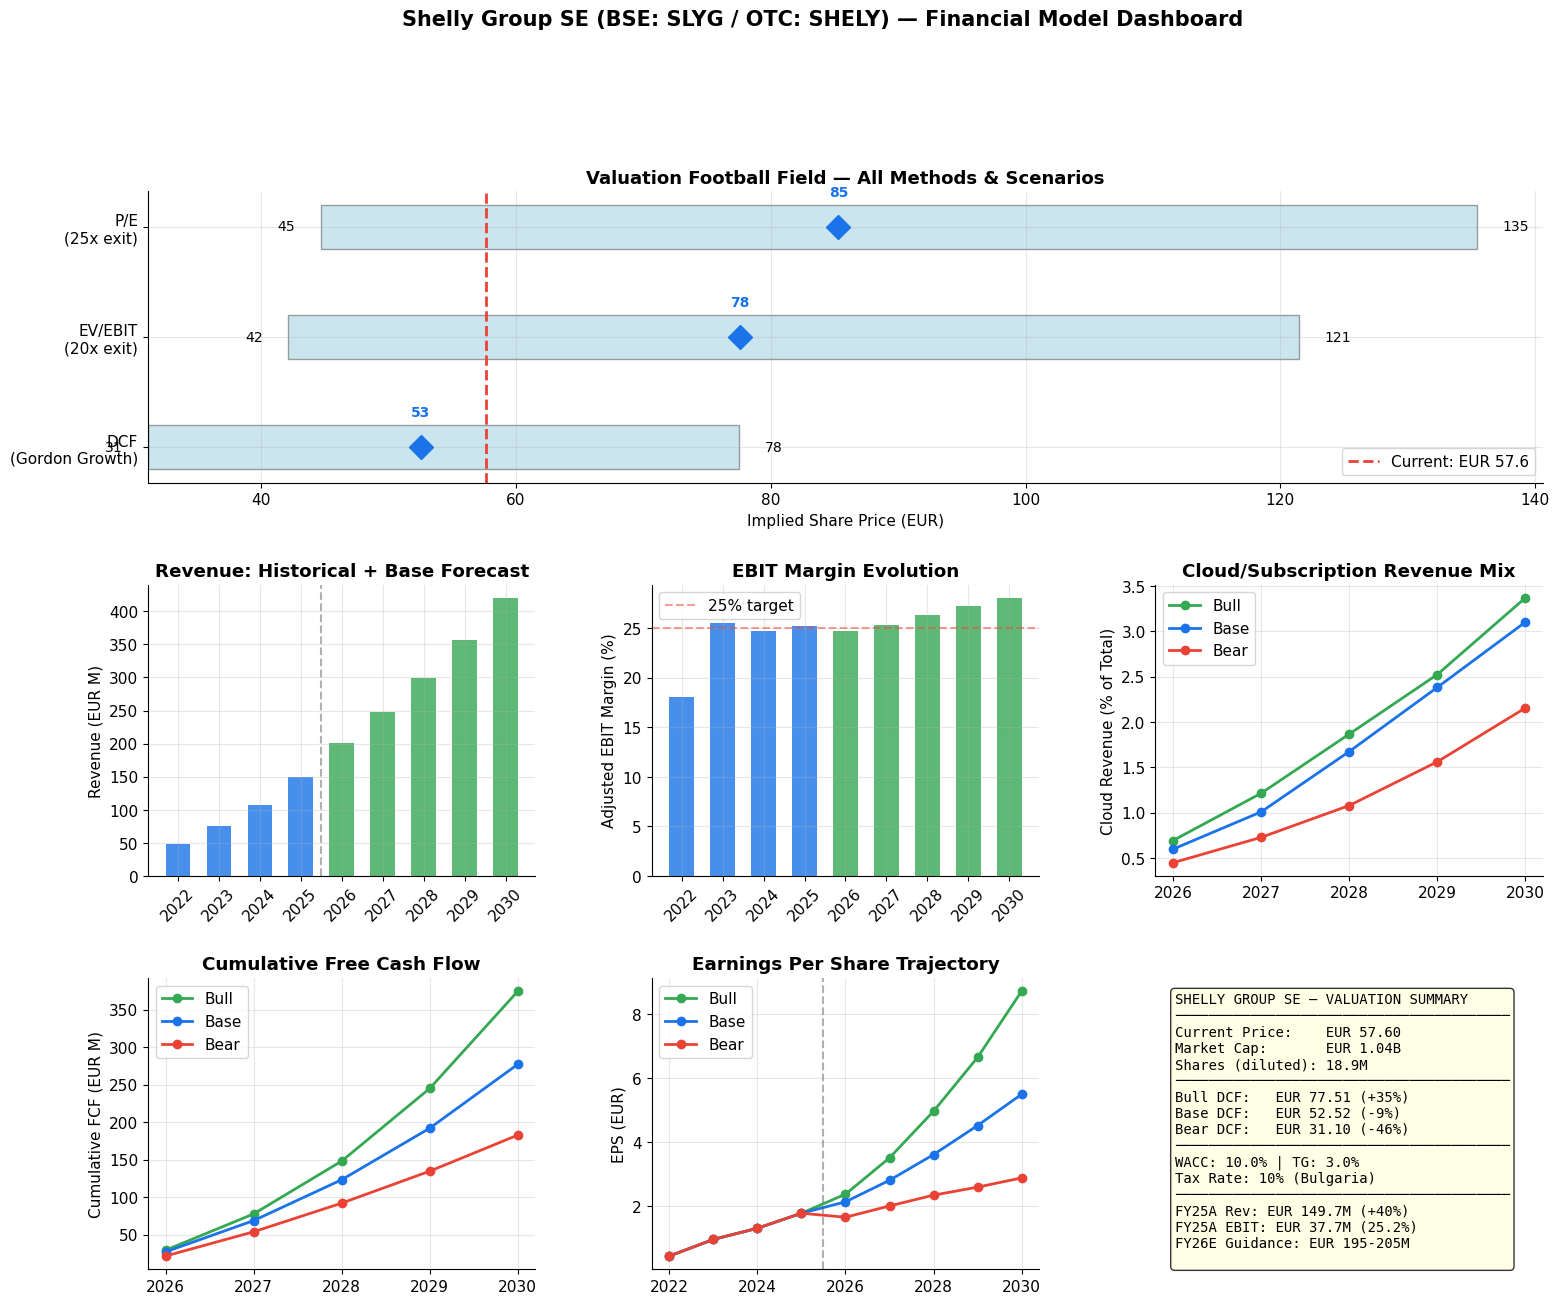


MODEL COMPLETE — All outputs generated successfully.


In [20]:
# ── Cell 25: Key Metrics Dashboard & Final Output ───────────

fig = plt.figure(figsize=(18, 14))

# Create grid
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1) Valuation Football Field
ax1 = fig.add_subplot(gs[0, :])
methods = ['DCF\n(Gordon Growth)', 'EV/EBIT\n(20x exit)', 'P/E\n(25x exit)']
bull_vals = []
base_vals = []
bear_vals = []

# DCF values
bull_vals.append(dcf_results['Bull']['Implied_Price'])
base_vals.append(dcf_results['Base']['Implied_Price'])
bear_vals.append(dcf_results['Bear']['Implied_Price'])

# EV/EBIT at 20x
for name, vals_list in [('Bull', bull_vals), ('Base', base_vals), ('Bear', bear_vals)]:
    ebit_2030 = projections[name].loc[2030, 'EBIT_Adj_K']
    ev = ebit_2030 * 20 + 13_600
    eq = ev / (18.9 * 1000)
    pv = eq / discount_5yr
    vals_list.append(pv)

# P/E at 25x
for name, vals_list in [('Bull', bull_vals), ('Base', base_vals), ('Bear', bear_vals)]:
    ni_2030 = projections[name].loc[2030, 'Net_Income_K']
    eq = ni_2030 * 25 / (18.9 * 1000)
    pv = eq / discount_5yr
    vals_list.append(pv)

y_pos = np.arange(len(methods))
for i, method in enumerate(methods):
    ax1.barh(i, bull_vals[i] - bear_vals[i], left=bear_vals[i], height=0.4,
             color=COLORS['light'], alpha=0.6, edgecolor=COLORS['neutral'])
    ax1.plot(base_vals[i], i, 'D', color=COLORS['primary'], markersize=12, zorder=5)
    ax1.text(bear_vals[i] - 2, i, f'{bear_vals[i]:.0f}', ha='right', va='center', fontsize=10)
    ax1.text(bull_vals[i] + 2, i, f'{bull_vals[i]:.0f}', ha='left', va='center', fontsize=10)
    ax1.text(base_vals[i], i + 0.25, f'{base_vals[i]:.0f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color=COLORS['primary'])

ax1.axvline(x=current_price, color=COLORS['accent'], linestyle='--', linewidth=2, label=f'Current: EUR {current_price}')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(methods)
ax1.set_xlabel('Implied Share Price (EUR)')
ax1.set_title('Valuation Football Field — All Methods & Scenarios', fontweight='bold', fontsize=13)
ax1.legend(fontsize=11)

# 2) Revenue bridge (historical -> projected Base)
ax2 = fig.add_subplot(gs[1, 0])
all_rev = pd.concat([income_stmt['Revenue'] / 1000, projections['Base']['Revenue_K'] / 1000])
colors_bridge = [COLORS['primary']] * 4 + [COLORS['secondary']] * 5
ax2.bar(all_rev.index, all_rev.values, color=colors_bridge, alpha=0.8, width=0.6)
ax2.axvline(x=2025.5, color=COLORS['neutral'], linestyle='--', alpha=0.5)
ax2.set_ylabel('Revenue (EUR M)')
ax2.set_title('Revenue: Historical + Base Forecast', fontweight='bold')
ax2.set_xticks(all_rev.index)
ax2.set_xticklabels([str(y) for y in all_rev.index], rotation=45)

# 3) EBIT margin evolution
ax3 = fig.add_subplot(gs[1, 1])
hist_em = income_stmt['EBIT_Margin_Adj']
proj_em = projections['Base']['EBIT_Margin_Adj_Pct']
all_em = pd.concat([hist_em, proj_em])
colors_em = [COLORS['primary']] * 4 + [COLORS['secondary']] * 5
ax3.bar(all_em.index, all_em.values, color=colors_em, alpha=0.8, width=0.6)
ax3.axhline(y=25, color=COLORS['accent'], linestyle='--', alpha=0.5, label='25% target')
ax3.set_ylabel('Adjusted EBIT Margin (%)')
ax3.set_title('EBIT Margin Evolution', fontweight='bold')
ax3.legend()
ax3.set_xticks(all_em.index)
ax3.set_xticklabels([str(y) for y in all_em.index], rotation=45)

# 4) Cloud revenue as % of total
ax4 = fig.add_subplot(gs[1, 2])
for name in ['Bull', 'Base', 'Bear']:
    pct = projections[name]['Cloud_Rev_K'] / projections[name]['Revenue_K'] * 100
    ax4.plot(proj_years, pct, 'o-', color=scenario_colors[name], linewidth=2, label=name)
ax4.set_ylabel('Cloud Revenue (% of Total)')
ax4.set_title('Cloud/Subscription Revenue Mix', fontweight='bold')
ax4.legend()

# 5) Cumulative FCF
ax5 = fig.add_subplot(gs[2, 0])
for name in ['Bull', 'Base', 'Bear']:
    cum = projections[name]['FCF_K'].cumsum() / 1000
    ax5.plot(proj_years, cum, 'o-', color=scenario_colors[name], linewidth=2, label=name)
ax5.set_ylabel('Cumulative FCF (EUR M)')
ax5.set_title('Cumulative Free Cash Flow', fontweight='bold')
ax5.legend()

# 6) EPS trajectory
ax6 = fig.add_subplot(gs[2, 1])
hist_eps = income_stmt['EPS_Adjusted']
for name in ['Bull', 'Base', 'Bear']:
    proj_eps = projections[name]['Net_Income_K'] / 18_900
    combined = pd.concat([hist_eps, proj_eps])
    ax6.plot(combined.index, combined.values, 'o-', color=scenario_colors[name],
             linewidth=2, label=name)
ax6.axvline(x=2025.5, color=COLORS['neutral'], linestyle='--', alpha=0.5)
ax6.set_ylabel('EPS (EUR)')
ax6.set_title('Earnings Per Share Trajectory', fontweight='bold')
ax6.legend()

# 7) Summary text box
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
summary_text = (
    f"SHELLY GROUP SE — VALUATION SUMMARY\n"
    f"{'─' * 40}\n"
    f"Current Price:    EUR {current_price:.2f}\n"
    f"Market Cap:       EUR 1.04B\n"
    f"Shares (diluted): 18.9M\n"
    f"{'─' * 40}\n"
    f"Bull DCF:   EUR {dcf_results['Bull']['Implied_Price']:.2f} ({(dcf_results['Bull']['Implied_Price']/current_price-1)*100:+.0f}%)\n"
    f"Base DCF:   EUR {dcf_results['Base']['Implied_Price']:.2f} ({(dcf_results['Base']['Implied_Price']/current_price-1)*100:+.0f}%)\n"
    f"Bear DCF:   EUR {dcf_results['Bear']['Implied_Price']:.2f} ({(dcf_results['Bear']['Implied_Price']/current_price-1)*100:+.0f}%)\n"
    f"{'─' * 40}\n"
    f"WACC: 10.0% | TG: 3.0%\n"
    f"Tax Rate: 10% (Bulgaria)\n"
    f"{'─' * 40}\n"
    f"FY25A Rev: EUR 149.7M (+40%)\n"
    f"FY25A EBIT: EUR 37.7M (25.2%)\n"
    f"FY26E Guidance: EUR 195-205M\n"
)
ax7.text(0.05, 0.95, summary_text, transform=ax7.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Shelly Group SE (BSE: SLYG / OTC: SHELY) — Financial Model Dashboard',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('/home/eyal/Downloads/financial analysis/SLYG/shely_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '=' * 60)
print('MODEL COMPLETE — All outputs generated successfully.')
print('=' * 60)